In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import shutil

In [4]:
dir_geom = 'convergence_tests/coated_sphere_4-5'
dir_run = 'convergence_tests/coated_sphere_4-5_runs'
dirso = os.listdir(dir_run)
dirso.sort()
dirso[3:]


['003', '004', '005', '006', '007', '008', '009']

In [41]:

kabs_list = []
matrix_11_list = []
runs = os.listdir(dir_run)
runs.sort()

for run in runs:
    with open(f'{dir_run}/{run}/results.dat', 'r') as f:
        l = f.readline()
        # skip header
        while l.startswith('#'):
            l=f.readline()
        # now at lambda line
        l=f.readline() #  break

        # comment some of these to pick which lambda result to plot
        l=f.readline() # first data line
        l=f.readline() # second 
        l=f.readline() # third
        
        kabs = float(l.split()[-1])
        lam = float(l.split()[0])
        kabs_list.append(kabs)

        while not l.startswith('#-'):
            l=f.readline()
        l=f.readline()
        l=f.readline() # first matrix line

        matrix_11s = []
        while not l.startswith('#'):
            matrix_11s.append( float(l.split()[1]))
            l=f.readline()
        matrix_11_list.append(matrix_11s)

len(kabs_list)


6

In [42]:


volumes = []
spheres = os.listdir(dir_geom)
spheres.sort()

for sphere in spheres:
    with open(f'{dir_geom}/{sphere}', 'r') as f:
        volume = 0
        l = f.readline()
        while l.startswith('#'):
            if l.startswith('# Volume1'):
                volume += int(l.split()[-1])
            if l.startswith('# Volume2'):
                volume += int(l.split()[-1])

            l=f.readline()
        
        volumes.append(volume)
len(volumes)
        

6

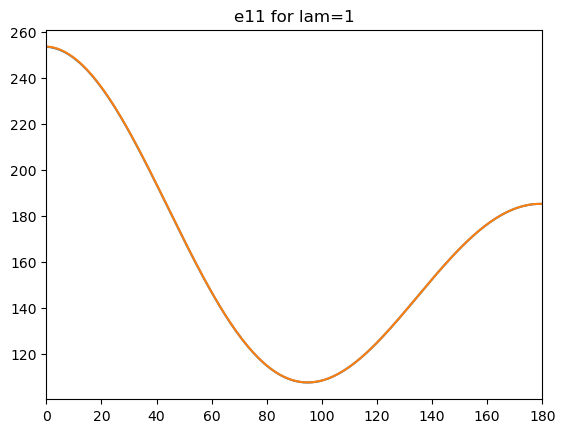

In [ ]:
for matrix_11s in matrix_11_list[4:]:
    plt.plot(range(181), matrix_11s)
plt.title('e11 for lam=1')
plt.xlim(0,180)
plt.show()

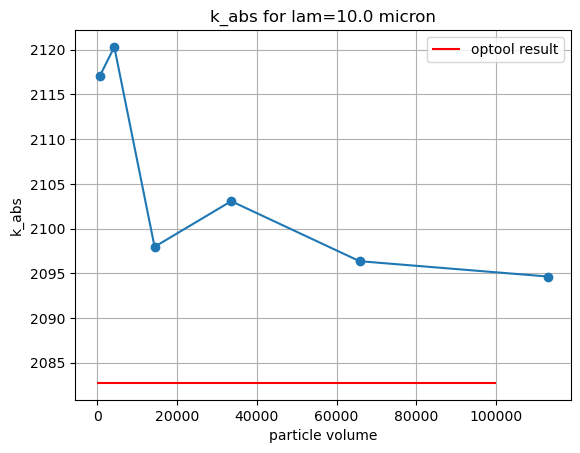

In [44]:
plt.plot(volumes, kabs_list, marker='o')
plt.title(f'k_abs for lam={lam} micron')
plt.ylabel('k_abs')
plt.xlabel('particle volume')
plt.grid()
ymin, ymax = plt.ylim()
# plt.vlines(1500, ymin,ymax, color='red')
# plt.hlines(7.016116E+03, 0, 12000, color='red', label='optool result')
plt.hlines(2.082738E+03
, 0, 100000, color='red', label='optool result')

plt.legend()
plt.show()

to plot a spectrum, we need to read in my own output file.

In [5]:
def read_in_file(file):
    file = open(file, 'r')
    line = file.readline()
    # header
    while line.startswith('#'):
        line = file.readline()
        if line.startswith('#   lmin'):
            nlam = int(float(line.split()[-3]))
            nang = int(line.split()[-1])

    
    lam_arr = np.zeros(nlam)
    kext_arr = np.zeros(nlam)
    kabs_arr = np.zeros(nlam)

    for i in range(nlam):
        lam_arr[i] = float(line.split()[0])
        kext_arr[i] = float(line.split()[5])
        kabs_arr[i] = float(line.split()[6])

        line = file.readline()
    
    file.close()
    print(nlam)
    return lam_arr, kext_arr, kabs_arr



    


In [7]:
file = 'runs/test_spectrum_big/results.dat'
lam, kext, kabs = read_in_file(file)

1000


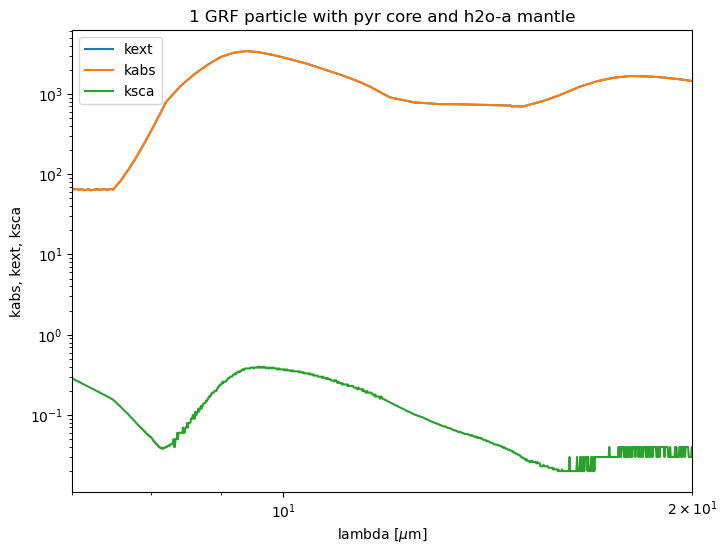

In [9]:
plt.figure(figsize=(8,6))
plt.title('1 GRF particle with pyr core and h2o-a mantle')
plt.plot(lam, kext, label='kext')
plt.plot(lam,kabs,label='kabs')
plt.plot(lam,kext - kabs,label='ksca')
ymin,ymax = plt.ylim()
# plt.vlines(18,ymin,ymax,color='red' )
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlim(lam[0], lam[-1])
plt.ylabel('kabs, kext, ksca')
plt.xlabel(r'lambda [$\mu$m]')
plt.show()


# checking particle library distribution
my general boudaries are about 0.5 for the mantle and idk yet about porosity

In [12]:
from pathlib import Path

# particle_files = os.listdir("generating_particles")

i = 1
mantle_frac_list = []
por_frac_list = []
name_list = []
for particle_file in Path("generating_particles").rglob("*.geom"):
    name_list.append(str(particle_file).split('/')[-1])
    rf = open(particle_file)
    # read in relevant header data
    mantle_volume = 0  # in case theres no mantle
    line = rf.readline()
    while line.startswith("#"):
        if line.startswith("# porosity_frac"):
            porosity_frac = float(line.split()[-1])
        elif line.startswith("# Volume1"):
            core_volume = float(line.split()[-1])
        elif line.startswith("# Volume2"):
            mantle_volume = float(line.split()[-1])
        line = rf.readline()

    rf.close()

    mantle_frac = mantle_volume / (mantle_volume + core_volume)
    mantle_frac_list.append(mantle_frac)
    por_frac_list.append(porosity_frac)
len(list(Path("generating_particles").rglob("*.geom")))

2361

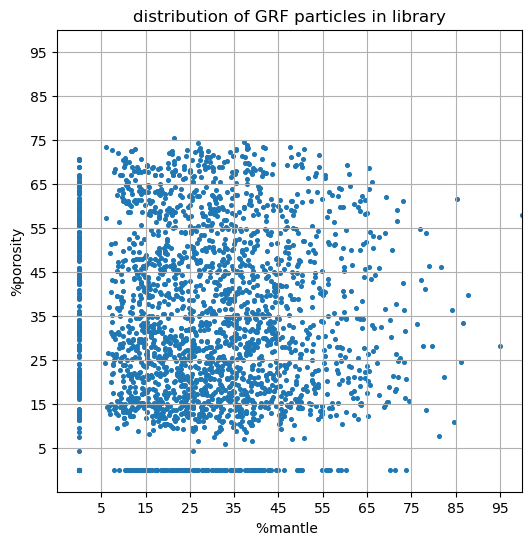

In [13]:
plt.figure(figsize=(6,6))

plt.scatter(mantle_frac_list, por_frac_list, s=7)
plt.xlabel('%mantle ')
plt.ylabel('%porosity')
plt.ylim(-0.05,1)
plt.xlim(-0.05,1)
plt.xticks(np.arange(0.05,1.01, 0.1), range(5,96, 10))
plt.yticks(np.arange(0.05,1.01, 0.1), range(5,96, 10))
plt.title('distribution of GRF particles in library')
plt.grid()
plt.show()


## selecting particles based on distance in this plot.
we have one central_central_point. lets say 0.3 mantle and 0.2 porosity. then we want the ten closest particles.

the coordinate is the distance to the origin. so the distance to out point is the difference between the coordinate and the point? and then the norm?

In [ ]:
from pathlib import Path


mantle_frac_list = []
por_frac_list = []
name_list = []

for particle_file in Path("GRF_particles").rglob("*.geom"):
    
    rf = open(particle_file)
    # read in relevant header data
    mantle_volume = 0  # in case theres no mantle
    line = rf.readline()
    while line.startswith("#"):
        if line.startswith("# porosity_frac"):
            porosity_frac = float(line.split()[-1])
        elif line.startswith("# Volume1"):
            core_volume = float(line.split()[-1])
        elif line.startswith("# Volume2"):
            mantle_volume = float(line.split()[-1])
        line = rf.readline()

    rf.close()

    mantle_frac = mantle_volume / (mantle_volume + core_volume)
    mantle_frac_list.append(mantle_frac)
    por_frac_list.append(porosity_frac)
    # name_list.append(str(particle_file).split('/')[-1])
    name_list.append(str(particle_file))
len(list(Path("generating_particles").rglob("*.geom")))

# name_list

['generating_particles/man1.07_por2.1999999999999997_/GRFpart18.geom',
 'generating_particles/man1.07_por2.1999999999999997_/GRFpart2.geom',
 'generating_particles/man1.06_por1.4_3/GRFpart9.geom',
 'generating_particles/man1.06_por1.4_3/GRFpart21.geom',
 'generating_particles/man1.06_por1.4_3/GRFpart2.geom',
 'generating_particles/man1.06_por1.4_3/GRFpart19.geom',
 'generating_particles/man1.02_por0.8_6/GRFpart9.geom',
 'generating_particles/man1.02_por0.8_6/GRFpart5.geom',
 'generating_particles/man1.02_por0.8_6/GRFpart16.geom',
 'generating_particles/man1.02_por0.8_6/GRFpart4.geom',
 'generating_particles/man1.02_por0.8_6/GRFpart17.geom',
 'generating_particles/man1.1_por0.8_2/GRFpart15.geom',
 'generating_particles/man1.09_por1.0_3/GRFpart0.geom',
 'generating_particles/man1.1_por2.4_2/GRFpart21.geom',
 'generating_particles/man1.1_por2.4_2/GRFpart13.geom',
 'generating_particles/man1.1_por2.4_2/GRFpart5.geom',
 'generating_particles/man1.1_por2.4_2/GRFpart10.geom',
 'generating_par

In [ ]:
central_point = (0.4,0.2) #central point (input parameters)
max_dist = 0.05 # not relevant anymore
closest_num = 100 #closest how many particles do you want

mantle_fracs = np.array(mantle_frac_list)
por_fracs = np.array(por_frac_list)
coordinates = np.stack((mantle_fracs, por_fracs), axis=-1)
distances_vec = coordinates - central_point
distances = np.linalg.norm(distances_vec, axis=1)

dist_name_tups = []
for i in range(len(distances)):
    # also add coordinates for plotting
    dist_name_tups.append((distances[i], name_list[i], coordinates[i]))

# select closest num. plot these
selection = sorted(dist_name_tups)[:closest_num]
x = [x[2][0] for x in selection]
y = [x[2][1] for x in selection]


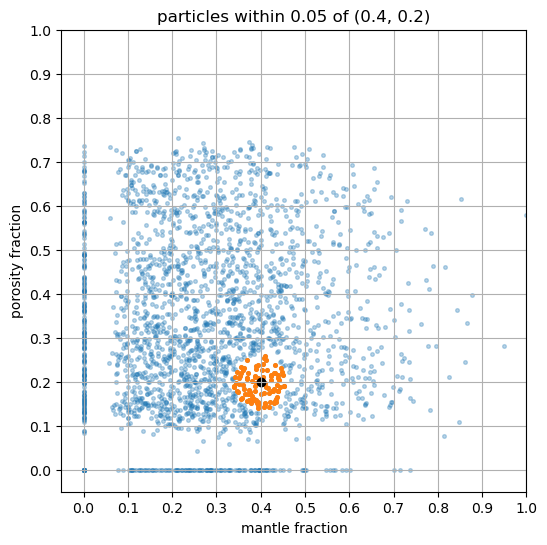

In [ ]:
# make the plot again
plt.figure(figsize=(6,6))

plt.scatter(mantle_frac_list, por_frac_list, s=7, alpha=0.3)
plt.scatter(x, y, s=7)
plt.scatter(central_point[0], central_point[1], color='black')
plt.xlabel('mantle fraction')
plt.ylabel('porosity fraction')
plt.ylim(-0.05,1)
plt.xlim(-0.05,1)
plt.xticks(np.arange(0,1.01, 0.1))
plt.yticks(np.arange(0,1.01, 0.1))
plt.title(f'particles within {max_dist} of {central_point}')
plt.grid()
plt.show()


### have to remove all of the Nmat lines in the no mantle files
move them to separate directory, then change my hand is what Im thinking. unless I can read in all those lines

In [11]:
import shutil
files = []
for particle_file in os.listdir('GRF_particles_all/'):
    
    rf = open(f'GRF_particles_all/{particle_file}', 'r')
    line = rf.readline()
    while line.startswith('#'):
        line = rf.readline()
    rf.close()
    # we are at Nmat line
    if line.startswith("Nmat=1"):
        shutil.move(f'GRF_particles_all/{particle_file}', f'GRF_particles_wd/{particle_file}')
    



In [ ]:
for particle_file in os.listdir('GRF_particles_wd/'):
    
    rf = open(f'GRF_particles_wd/{particle_file}', 'r')
    line = rf.readline()
    while line.startswith('#'):
        line = rf.readline()
    rf.close()


In [ ]:
# this is to find the string for the directory. probably dont need this
# mantle_bin = int(floor(mantle_frac * 10 + 0.5) * 10)

man_frac = 0.62
por_frac = 0.1
f'{mantle_frac}'
f'/mantle_{man_frac}por_{por_frac}'

## testing the volume calculation with porosity

$\rho_{core}=3.01$ <br>
$\rho_{mantle}=0.92$ <br>
mass fractions core 0.8 mantle 0.2 <br>

with no porosity, $\rho_{tot}=2.07$ <br>
with 10% porosity, $\rho_{tot}=1.86$

my volume percentage is $V_{m}= \frac{\rho_{tot}-\rho_{c}}{\rho_{m}-\rho_{c}}$ so the lower my $\rho_{tot}$, the lower my mantle percentage. of course its not correct to say the core and mantle densities dont change with porosity. its a mix with vacuum already. so those should also change, they all change with a factor of $(1-V_p$).

Good test: calculate this with all values (core mantle and total) $V_p=0.2$ added and with no porosity.


In [5]:
rho_c_por = 2.41
rho_c = 3.01

rho_m_por = 0.74
rho_m = 0.92

rho_tot_por = 1.66
rho_tot = 2.07

vol_frac_por = (rho_tot_por-rho_c_por)/(rho_m_por-rho_c_por)
vol_frac = (rho_tot-rho_c)/(rho_m-rho_c)
print(f'{vol_frac_por:.3f}')
print(f'{vol_frac:.3f}')



0.449
0.450


In [ ]:
def format_time_str(seconds):

    # Use timedelta for easy calculation of hours, minutes, and seconds
    td = datetime.timedelta(seconds=seconds)
    hours, remainder = divmod(td.seconds, 3600)
    minutes, seconds = divmod(remainder, 60)

    parts = []
    if hours > 0:
        parts.append(f"{hours}h")
    if minutes > 0:
        parts.append(f"{minutes}m")
    if seconds > 0:
        parts.append(f"{seconds}s")
    
    # If the time is 0 seconds, we still want to show "0s"
    if not parts:
        return "0s"

    return " ".join(parts)

make plot for showing multicore performance

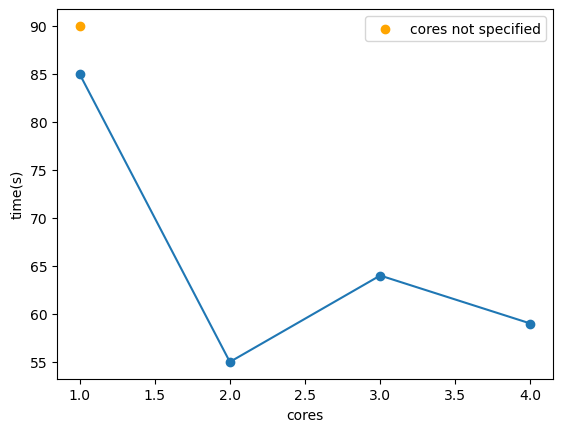

second run with more particles, same lambdas

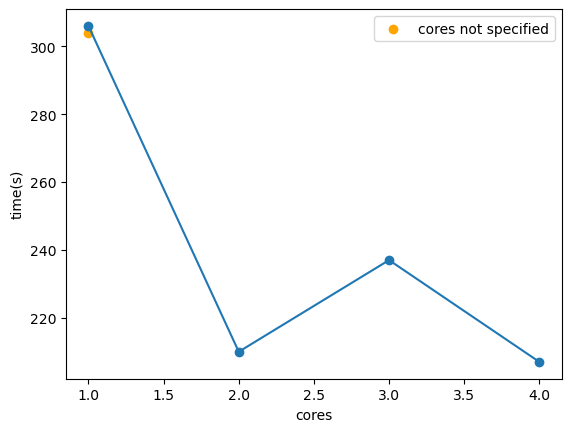

In [16]:
cores_used = [1,2,3,4]
time_s = [306, 210, 237, 207]

plt.plot(cores_used, time_s, marker='o')
plt.scatter(1,304,label='cores not specified', color='orange')
plt.xlabel('cores')
plt.ylabel('time(s)')
plt.legend()
plt.show()


one more test where i try to make him do really annoying calculations? what would take long. besides generating a big particle.

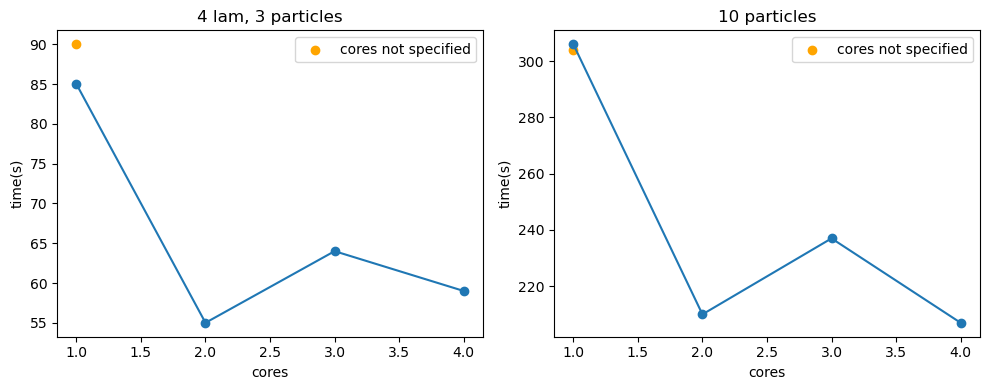

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

cores_used = [1,2,3,4]
time_s = [85,55, 64, 59]
ax[0].scatter(1,90,label='cores not specified', color='orange')
ax[0].plot(cores_used, time_s, marker='o')
ax[0].set_title('4 lam, 3 particles')
ax[0].set_xlabel('cores')
ax[0].set_ylabel('time (s)')


cores_used = [1,2,3,4]
time_s = [306, 210, 237, 207]
ax[1].plot(cores_used, time_s, marker='o')
ax[1].scatter(1,304,label='cores not specified', color='orange')
ax[1].set_title('10 particles')
ax[1].set_xlabel('cores')
ax[1].set_ylabel('time (s)')

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()